In [1]:
import pandas as pd
import numpy as np

In [2]:
data=pd.read_csv("spam_ham.txt",sep='\t',header=None)
pd.set_option("display.max_colwidth",None)

In [3]:
data

,0,1
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives around here though"
...,...,...
5567,spam,"This is the 2nd time we have tried 2 contact u. U have won the £750 Pound prize. 2 claim is easy, call 087187272008 NOW1! Only 10p per minute. BT-national-rate."
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other suggestions?"
5570,ham,The guy did some bitching but I acted like i'd be interested in buying something else next week and he gave it to us for free


In [4]:
data=data.rename(columns={0:"Target",1:"Text"})

In [5]:
data.head()

,Target,Text
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives around here though"


In [6]:
data.tail()

,Target,Text
5567,spam,"This is the 2nd time we have tried 2 contact u. U have won the £750 Pound prize. 2 claim is easy, call 087187272008 NOW1! Only 10p per minute. BT-national-rate."
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other suggestions?"
5570,ham,The guy did some bitching but I acted like i'd be interested in buying something else next week and he gave it to us for free
5571,ham,Rofl. Its true to its name


In [7]:
data.shape

(5572, 2)

In [8]:
data.isnull().sum()

Target    0
Text      0
dtype: int64

In [9]:
data.duplicated().sum()

np.int64(403)

In [10]:
data=data.drop_duplicates()

In [11]:
data.duplicated().sum()

np.int64(0)

In [12]:
data.shape

(5169, 2)

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5169 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Target  5169 non-null   object
 1   Text    5169 non-null   object
dtypes: object(2)
memory usage: 121.1+ KB


In [14]:
target_count=data['Target'].value_counts()
target_count

Target
ham     4516
spam     653
Name: count, dtype: int64

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

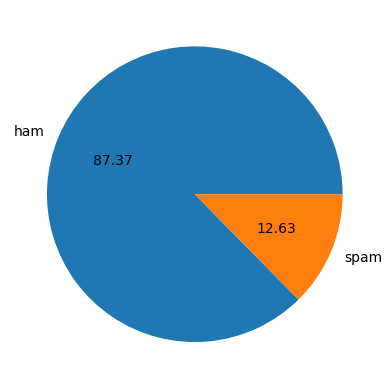

In [16]:
plt.pie(target_count,autopct='%.2f',labels=['ham','spam'])
plt.show()

In [17]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
data['Target']=encoder.fit_transform(data['Target'])

In [18]:
data.sample(5)

,Target,Text
901,0,Probably money worries. Things are coming due and i have several outstanding invoices for work i did two and three months ago.
1865,0,You call him now ok i said call him
4790,0,We're on the opposite side from where we dropped you off
4107,0,K then 2marrow are you coming to class.
2169,0,Thx. All will be well in a few months


In [19]:
#nltk.download()

In [20]:
import nltk
import re
from nltk.corpus import stopwords

In [21]:
StopWords=stopwords.words("english")

In [22]:
def text_cleaning(text):
    text=re.sub(r"[^a-z\s]","",text.lower()).strip()
    text=re.sub(r"\s+"," ",text)
    tokens=nltk.word_tokenize(text)
    Text=[]
    for token in tokens:
        if token not in StopWords:
            Text.append(token)    
            
    return " ".join(Text)


In [23]:
data['Clean_Text']=data['Text'].apply(text_cleaning)

In [24]:
data.sample(5)

,Target,Text,Clean_Text
5385,0,How do friends help us in problems? They give the most stupid suggestion that Lands us into another problem and helps us forgt the previous problem,friends help us problems give stupid suggestion lands us another problem helps us forgt previous problem
423,0,Siva is in hostel aha:-.,siva hostel aha
2663,1,"Hello darling how are you today? I would love to have a chat, why dont you tell me what you look like and what you are in to sexy?",hello darling today would love chat dont tell look like sexy
2924,0,Fine am simply sitting.,fine simply sitting
1065,0,"That's fine, I'll bitch at you about it later then",thats fine ill bitch later


In [25]:
#pip install wordcloud

In [26]:
from wordcloud import WordCloud
spam_clean_text=data[data['Target']==1]['Clean_Text'].str.cat()

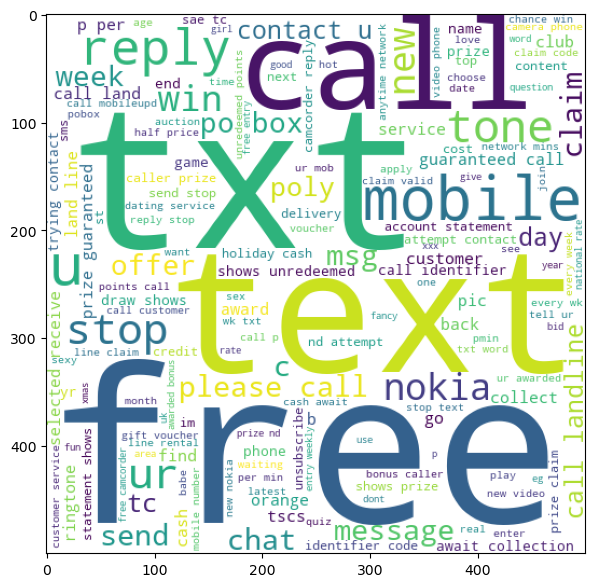

In [27]:
wc=WordCloud(min_font_size=8,width=500,height=500,background_color='White')
spam_wordcloud=wc.generate(spam_clean_text)
plt.figure(figsize=(12,7))
plt.imshow(spam_wordcloud)

In [28]:
ham_clean_text=data[data['Target']==0]['Clean_Text'].str.cat()

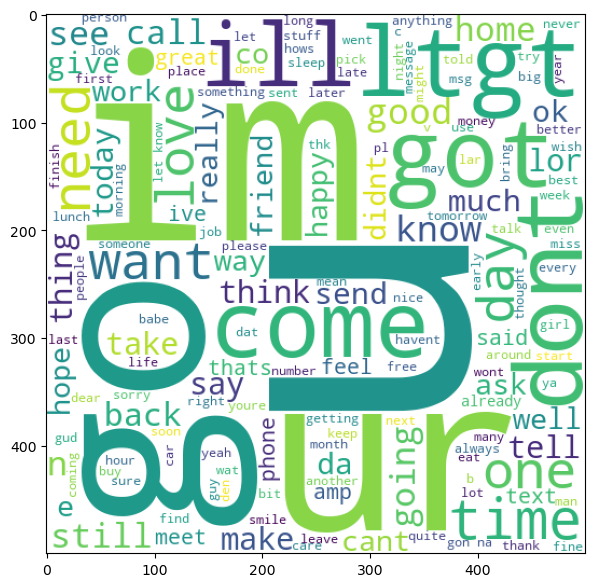

In [29]:
ham_wordcloud=wc.generate(ham_clean_text)
plt.figure(figsize=(12,7))
plt.imshow(ham_wordcloud)

In [30]:
#data[data['Target']==1]['Clean_Text'].tolist()

In [31]:
token_spam_msg=[]
for spam in data[data['Target']==1]['Clean_Text'].tolist():
    #print(spam)
    for word in spam.split():
        token_spam_msg.append(word)
        
print("Total Spam Word -",len(token_spam_msg))


token_ham_msg=[]
for ham in data[data['Target']==0]['Clean_Text'].tolist():
    #print(ham)
    for word in ham.split():
        token_ham_msg.append(word)

print("Total Ham Word -",len(token_ham_msg))

Total Spam Word - 9241
Total Ham Word - 36359


In [32]:
from collections import Counter
spam_count=Counter(token_spam_msg).most_common(20)
df_spam=pd.DataFrame(spam_count)
df_spam.head(2)

,0,1
0,call,306
1,free,190


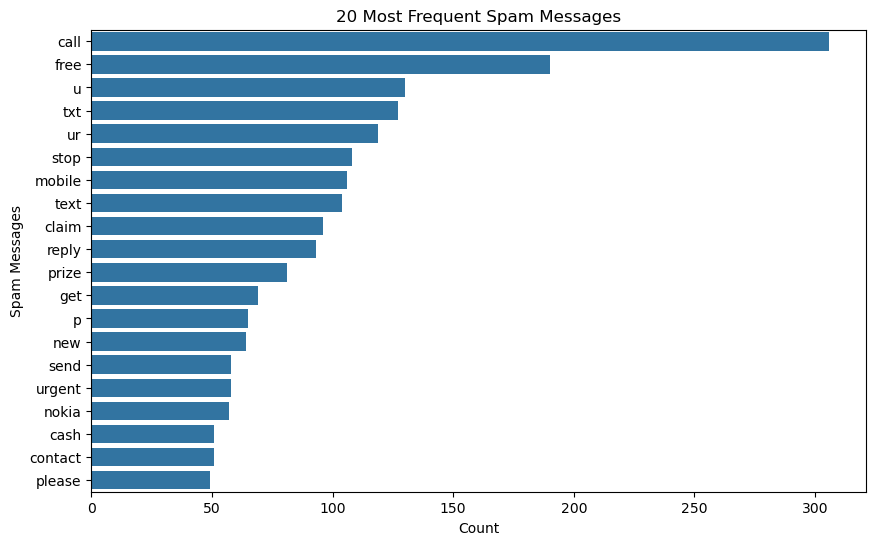

In [33]:
plt.figure(figsize=(10,6))
sns.barplot(y=df_spam[0],x=df_spam[1])
plt.title("20 Most Frequent Spam Messages")
plt.xlabel("Count")
plt.ylabel("Spam Messages")
plt.show()

In [34]:
ham_count=Counter(token_ham_msg).most_common(20)
df_ham=pd.DataFrame(ham_count)
df_ham.head(2)

,0,1
0,u,903
1,im,448


In [35]:
#pip install seaborn

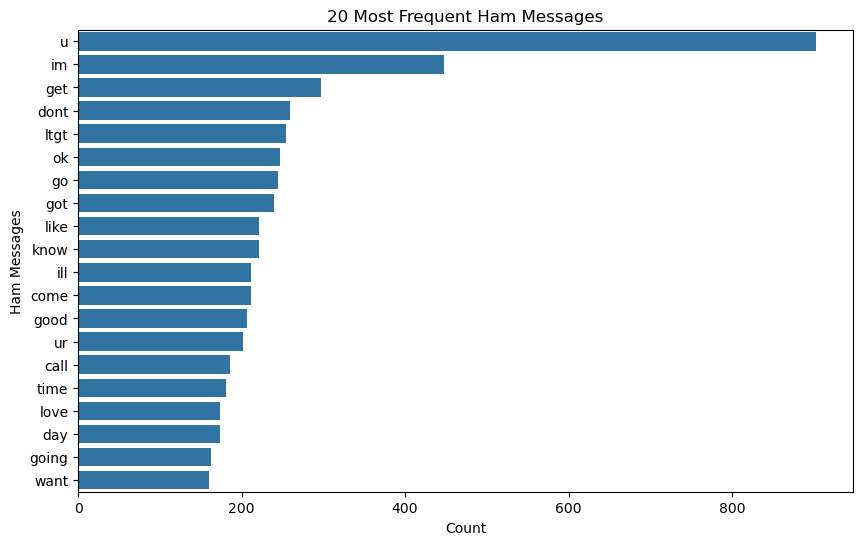

In [36]:
plt.figure(figsize=(10,6))
sns.barplot(y=df_ham[0],x=df_ham[1])
plt.title("20 Most Frequent Ham Messages")
plt.xlabel("Count")
plt.ylabel("Ham Messages")
plt.show()

In [37]:
X=data['Clean_Text']
X

0                                go jurong point crazy available bugis n great world la e buffet cine got amore wat
1                                                                                           ok lar joking wif u oni
2       free entry wkly comp win fa cup final tkts st may text fa receive entry questionstd txt ratetcs apply overs
3                                                                               u dun say early hor u c already say
4                                                                       nah dont think goes usf lives around though
                                                           ...                                                     
5567                              nd time tried contact u u pound prize claim easy call p per minute btnationalrate
5568                                                                                      b going esplanade fr home
5569                                                                    

In [38]:
X.shape

(5169,)

In [39]:
y=data['Target'].values

In [40]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [41]:
from sklearn.model_selection import train_test_split

In [42]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.2,random_state=5)

In [43]:
print("X train -",X_train.shape)
print("X test -",X_test.shape)
print("y train -",y_train.shape)
print("y test -",y_test.shape)

X train - (4135,)
X test - (1034,)
y train - (4135,)
y test - (1034,)


In [44]:
from sklearn.feature_extraction.text import TfidfVectorizer
tv=TfidfVectorizer(stop_words='english',max_features=2000)
X_train=tv.fit_transform(X_train).toarray()
X_test=tv.transform(X_test).toarray()
print("Tfidf X_train",(X_train))
print("Tfidf X_test",(X_test))

Tfidf X_train [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
Tfidf X_test [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [45]:
tv.get_feature_names_out()

array(['aah', 'abi', 'ability', ..., 'yup', 'zed', 'zoe'], dtype=object)

In [46]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

In [47]:
gnb=GaussianNB()
mnb=MultinomialNB()
bnb=BernoulliNB()

In [48]:
model={'GaussianNB':gnb,'MultinomialNB':mnb,'BernoulliNB':bnb}
print(model)

{'GaussianNB': GaussianNB(), 'MultinomialNB': MultinomialNB(), 'BernoulliNB': BernoulliNB()}


In [49]:
def model_train_classifier(model,X_train,y_train,X_test,y_test):
    model.fit(X_train,y_train)
    y_train_pred=model.predict(X_train)
    y_test_pred=model.predict(X_test)

    Training_accuracy_score=accuracy_score(y_train,y_train_pred)
    Testing_accuracy_score=accuracy_score(y_test,y_test_pred)

    Training_precision_score=precision_score(y_train,y_train_pred)
    Testing_precision_score=precision_score(y_test,y_test_pred)

    Training_recall_score=recall_score(y_train,y_train_pred)
    Testing_recall_score=recall_score(y_test,y_test_pred)

    Training_f1_score=f1_score(y_train,y_train_pred)
    Testing_f1_score=f1_score(y_test,y_test_pred)

    
    return Training_accuracy_score,Testing_accuracy_score,Training_precision_score,Testing_precision_score,Training_recall_score,Testing_recall_score,Training_f1_score,Testing_f1_score

In [50]:
Training_Accuracy_Score=[]
Testing_Accuracy_Score=[]

Training_Precision_Score=[]
Testing_Precision_Score=[]

Training_Recall_Score=[]
Testing_Recall_Score=[]

Training_F1_Score=[]
Testing_F1_Score=[]


for name,model in model.items():
    Training_accuracy_score,Testing_accuracy_score,Training_precision_score,Testing_precision_score,Training_recall_score,Testing_recall_score,Training_f1_score,Testing_f1_score=model_train_classifier(model,X_train,y_train,X_test,y_test)  
   
    Training_Accuracy_Score.append(Training_accuracy_score)
    Testing_Accuracy_Score.append(Testing_accuracy_score)

    Training_Precision_Score.append(Training_precision_score)
    Testing_Precision_Score.append(Testing_precision_score)

    Training_Recall_Score.append(Training_recall_score)
    Testing_Recall_Score.append(Testing_recall_score)

    Training_F1_Score.append(Training_f1_score)
    Testing_F1_Score.append(Testing_f1_score)



In [51]:
dataframe=pd.DataFrame({"Model":['GaussianNb','MultinomialNB','BernoulliNB'],
              "Training Accuracy Score":Training_Accuracy_Score,
              "Testing Accuracy Score":Testing_Accuracy_Score,
              "Training Precision Score":Training_Precision_Score,
              "Testing Precision Score":Testing_Precision_Score,
              "Training Recall Score":Training_Recall_Score,
              "Testing Recall Score":Testing_Recall_Score,
              "Training F1 Score":Training_F1_Score,
              "Testing F1 Score":Testing_F1_Score
             })
dataframe

,Model,Training Accuracy Score,Testing Accuracy Score,Training Precision Score,Testing Precision Score,Training Recall Score,Testing Recall Score,Training F1 Score,Testing F1 Score
0,GaussianNb,0.870375,0.808511,0.500466,0.360544,1.000000,0.913793,0.667081,0.517073
1,MultinomialNB,0.978235,0.975822,0.995565,0.959596,0.836127,0.818966,0.908907,0.883721
2,BernoulliNB,0.982104,0.978723,0.991507,0.979592,0.869646,0.827586,0.926587,0.897196


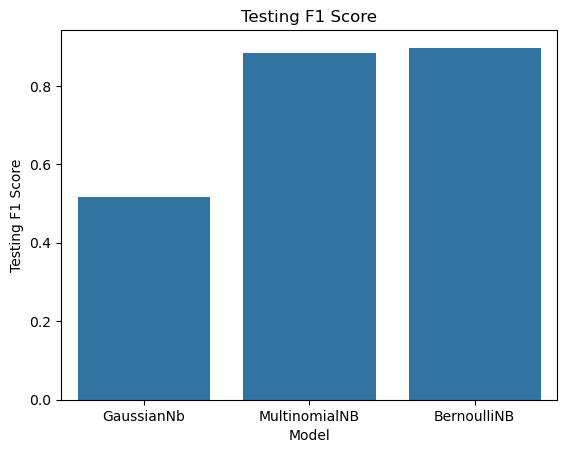

In [52]:
sns.barplot(x=dataframe["Model"],y=dataframe["Testing F1 Score"])
plt.title("Testing F1 Score")
plt.show()

In [53]:
data.sample(5)

,Target,Text,Clean_Text
4428,0,So what did the bank say about the money?,bank say money
4248,1,Text PASS to 69669 to collect your polyphonic ringtones. Normal gprs charges apply only. Enjoy your tones,text pass collect polyphonic ringtones normal gprs charges apply enjoy tones
2392,0,PICK UR FONE UP NOW U DUMB?,pick ur fone u dumb
2767,1,Married local women looking for discreet action now! 5 real matches instantly to your phone. Text MATCH to 69969 Msg cost 150p 2 stop txt stop BCMSFWC1N3XX,married local women looking discreet action real matches instantly phone text match msg cost p stop txt stop bcmsfwcnxx
5370,1,dating:i have had two of these. Only started after i sent a text to talk sport radio last week. Any connection do you think or coincidence?,datingi two started sent text talk sport radio last week connection think coincidence


In [54]:
X=data['Clean_Text'].values
X

array(['go jurong point crazy available bugis n great world la e buffet cine got amore wat',
       'ok lar joking wif u oni',
       'free entry wkly comp win fa cup final tkts st may text fa receive entry questionstd txt ratetcs apply overs',
       ..., 'pity mood soany suggestions',
       'guy bitching acted like id interested buying something else next week gave us free',
       'rofl true name'], dtype=object)

In [55]:
y=data['Target'].values
y

array([0, 0, 1, ..., 0, 0, 0])

In [56]:
tv=TfidfVectorizer(stop_words='english',max_features=2000)
tfidf_X=tv.fit_transform(X).toarray()
tfidf_X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [57]:
import joblib

In [58]:
joblib.dump(text_cleaning,'Text Cleaning')


['Text Cleaning']

In [59]:
Text_Cleaning=joblib.load('Text Cleaning')
Text_Cleaning

<function __main__.text_cleaning(text)>

In [60]:
joblib.dump(tv,"Spam_Detection_Tfidf_Vectorizer")

['Spam_Detection_Tfidf_Vectorizer']

In [61]:
tfidf=joblib.load('Spam_Detection_Tfidf_Vectorizer')
tfidf

TfidfVectorizer(max_features=2000, stop_words='english')

In [62]:
tv.get_feature_names_out()

array(['abi', 'abiola', 'able', ..., 'yun', 'yup', 'zed'], dtype=object)

In [63]:
model_mnb=MultinomialNB()
model_mnb.fit(tfidf_X,y)


MultinomialNB()

In [64]:
joblib.dump(model_mnb,"Spam_Detection_Model")

['Spam_Detection_Model']

In [65]:
Multinomial_model=joblib.load('Spam_Detection_Model')

In [66]:
#input_text=["Congratulations! You’ve been selected to win a $1,000 gift card! Claim it now:"]
input_text=["Hey, just checking in to see how your day went. Want to grab coffee tomorrow?"]
#input_text=["ex up ur mobile with a FREE sexy pic of Jordan! Just text BABE to 88600. Then every wk get a sexy celeb! PocketBabe.co.uk 4 more pics. 16 £3/wk 087016248"]
input_df=pd.DataFrame(input_text)
input_df

,0
0,"Hey, just checking in to see how your day went. Want to grab coffee tomorrow?"


In [67]:
input_df[0]

0    Hey, just checking in to see how your day went. Want to grab coffee tomorrow?
Name: 0, dtype: object

In [68]:
input_text_clean=input_df[0].apply(Text_Cleaning)
input_text_clean

0    hey checking see day went want grab coffee tomorrow
Name: 0, dtype: object

In [69]:
input_data_vector=tfidf.transform(input_text_clean).toarray()
input_data_vector

array([[0., 0., 0., ..., 0., 0., 0.]])

In [70]:
prediction=Multinomial_model.predict(input_data_vector)
prediction

array([0])

In [71]:
if prediction[0]==0:
    print("Ham Message")
else:
    print("Spam Message")

Ham Message


In [72]:
from tkinter import *
from tkinter import messagebox

root=Tk()

root.title("Spam Message Detection Using NLP")
root.geometry("900x600")
root.minsize(300,300)
#root.maxsize(500,500)
root.configure(bg="#FF004F")

header=Label(root,text="Spam Message Detection",bg='#FF004F',fg='Black',font=('Times New Roman',30,'bold'))
header.pack(pady=25)

frame=Frame(root,bg='#FF004F')
frame.pack()

label=Label(frame,text="Enter The Message",bg='#FF004F',fg='white',font=("Times New Roman",15)).grid(row=0,column=0,sticky="w")

text_box=Text(frame,width=70,height=10,font=('Times New Roman',15),borderwidth=6)
text_box.grid(row=1,columnspan=2)
#text_box.grid(row=1, column=0, columnspan=2)


def get_input():
    text = text_box.get("1.0", END).strip()#"1.0" means first line, first character.
    #text = text_box.get("1.0", "end-1c").strip()
    df_show=pd.DataFrame([text])
    clean_text=df_show[0].apply(Text_Cleaning)
    vector=tfidf.transform(clean_text).toarray()
    prediction=Multinomial_model.predict(vector)


    if prediction[0] == 0:
       messagebox.showinfo("Result", "Ham Message")
    else:
       messagebox.showinfo("Result", "Spam Message")



        

button=Button(root,text=" Predict ",borderwidth=5,width=6,font=("Times New Roman",15,'bold'),command=get_input)
button.pack(pady=20)

root.mainloop()

In [73]:
#input_text=["Congratulations! You’ve been selected to win a $1,000 gift card! Claim it now:"]
#input_text=["Hey, just checking in to see how your day went. Want to grab coffee tomorrow?"]
#text_box="Am not working but am up to eyes in philosophy so will text u later when a bit more free for chat..."
#text_box=["Well done ENGLAND! Get the official poly ringtone or colour flag on yer mobile! text TONE or FLAG to 84199 NOW! Opt-out txt ENG STOP. Box39822 W111WX £1.50